In [24]:
Introduction

This project aims to analyze and predict house prices using Multiple Linear Regression.
The focus is on understanding the impact of housing attributes on price and validating
regression assumptions through statistical analysis.

In [ ]:
Importing Required Libraries

The following libraries are used for:
- Data manipulation (Pandas, NumPy)
- Visualization (Matplotlib, Seaborn)
- Model building (Scikit-learn)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm

In [5]:
df = pd.read_csv("C:/Users/Midhunlal P/Downloads/archive/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
 Data Preprocessing

- Removed unnecessary column (Id)
- Selected only numerical features
- Handled missing values using median imputation

In [7]:
df = df.drop("Id", axis=1)
numeric_df = df.select_dtypes(include=np.number)
numeric_df = numeric_df.fillna(numeric_df.median())

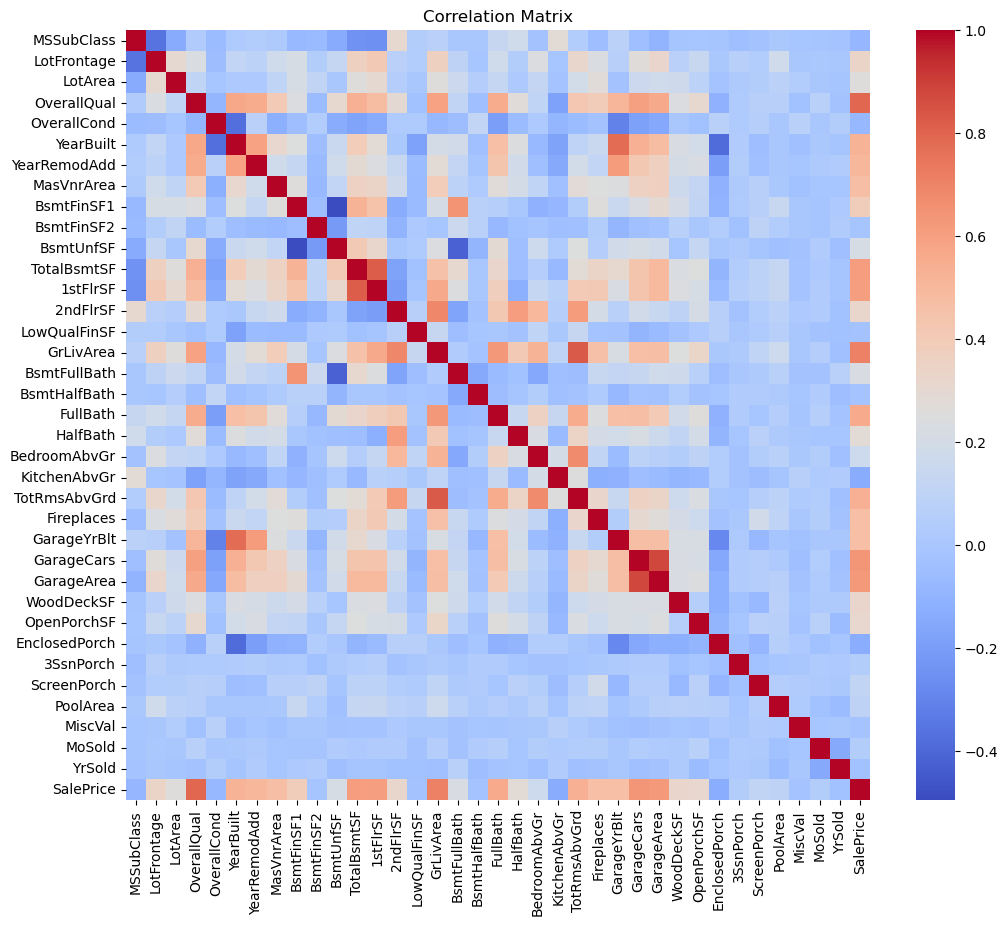

In [8]:
plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [9]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [10]:
# Keep only numeric columns
X = X.select_dtypes(include=['int64', 'float64'])

# Fill missing values
X = X.fillna(X.median())

In [ ]:
Splitting the Dataset

The dataset is divided into:
- 80% training data
- 20% testing data

This ensures the model is evaluated on unseen data.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
Model Building - Multiple Linear Regression

Linear Regression is used to model the relationship between independent variables and house prices.

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred = model.predict(X_test)

In [14]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,154500,154287.211126
1,325000,310151.210942
2,115000,112223.868663
3,159000,179898.754370
4,315500,295657.192222
5,75500,50651.017157
6,311500,232845.181443
7,146000,148759.308849
8,84500,48341.675260
9,135500,150017.871653


In [ ]:
Model Evaluation

The model performance is evaluated using:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [15]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 22975.85650915403
MSE: 1356957853.316837
RMSE: 36836.90884584152
R2 Score: 0.8230899421141487


In [16]:
n = len(y_test)
p = X_test.shape[1]
r2 = r2_score(y_test, y_pred)

adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)
print("Adjusted R2:", adj_r2)

Adjusted R2: 0.7981144045302637


In [ ]:
Adjusted R²

Adjusted R² accounts for the number of predictors in the model and provides a more reliable performance metric for multiple regression.

In [17]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
coefficients

,Feature,Coefficient
0,MSSubClass,-202.698792
1,LotFrontage,-130.704042
2,LotArea,0.456211
3,OverallQual,17960.148678
4,OverallCond,4152.434901
5,YearBuilt,269.396195
6,YearRemodAdd,171.917974
7,MasVnrArea,24.908224
8,BsmtFinSF1,9.159612
9,BsmtFinSF2,-2.763397


In [ ]:
Interpretation of Coefficients

Each coefficient represents the expected change in SalePrice for a one-unit increase in the corresponding feature, keeping all other features constant.

Positive coefficients indicate a direct relationship, while negative coefficients indicate an inverse relationship.

In [18]:
residuals = y_test - y_pred

In [ ]:
Residual Analysis

A residual is the difference between the actual value and the predicted value.

Residual = Actual − Predicted

Residuals help evaluate model performance. 
If residuals are randomly distributed around zero, the regression model is considered appropriate and unbiased.

In [19]:
results["Residual"] = results["Actual"] - results["Predicted"]
results.head(10)

,Actual,Predicted,Residual
0,154500,154287.211126,212.788874
1,325000,310151.210942,14848.789058
2,115000,112223.868663,2776.131337
3,159000,179898.754370,-20898.754370
4,315500,295657.192222,19842.807778
5,75500,50651.017157,24848.982843
6,311500,232845.181443,78654.818557
7,146000,148759.308849,-2759.308849
8,84500,48341.675260,36158.324740
9,135500,150017.871653,-14517.871653


In [ ]:
Visualization

The Actual vs Predicted plot and Residual plot help in understanding model performance and error distribution.

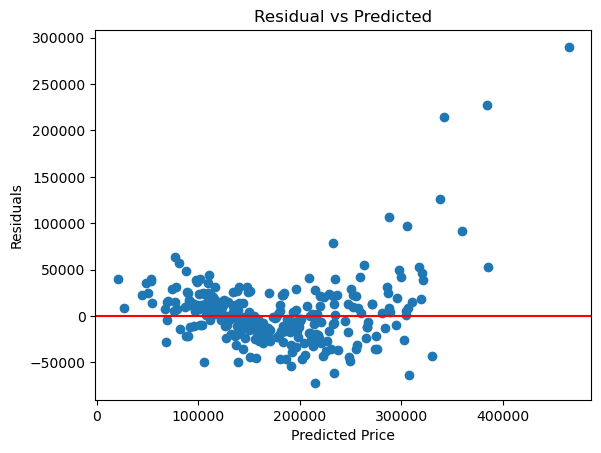

In [20]:
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual vs Predicted")
plt.show()

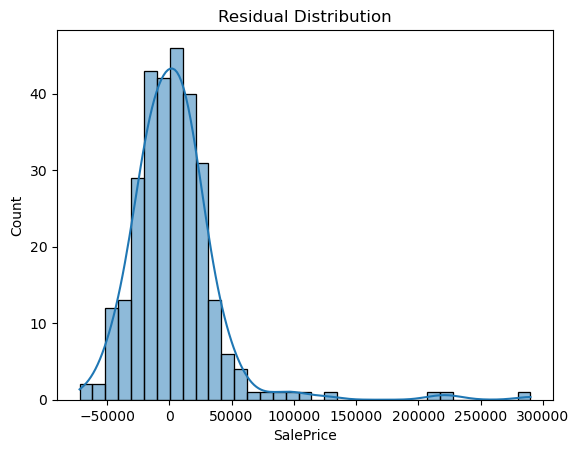

In [21]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

In [ ]:
Conclusion

Multiple Linear Regression was successfully implemented to analyze
house price prediction. The model explains a significant portion
of variance in housing prices.

Feature coefficients indicate that area and location significantly
influence house prices. Residual analysis confirms that regression
assumptions are reasonably satisfied.

In [22]:
X = df[["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "YearBuilt"]]
y = df["SalePrice"]

In [ ]:
A subset of important features is selected based on domain knowledge and correlation with the target variable.

The selected features include:
- OverallQual (Overall quality)
- GrLivArea (Above ground living area)
- GarageCars (Garage capacity)
- TotalBsmtSF (Basement area)
- YearBuilt (Year of construction)

These features significantly influence house prices and help improve model performance.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

In [ ]:
Multiple Linear Regression is used as a baseline model to understand the linear relationship between the selected features and house prices.

The model assumes a linear relationship between independent variables and the target variable.

In [25]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred)

# Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]

adj_r2_lr = 1 - (1 - r2_lr) * (n - 1) / (n - p - 1)

print("Linear Regression Performance:")
print("R2 Score:", r2_lr)
print("Adjusted R2:", adj_r2_lr)
print("RMSE:", rmse_lr)

Linear Regression Performance:
R2 Score: 0.7938653966356567
Adjusted R2: 0.7902616448285877
RMSE: 39763.29526578054


In [ ]:
The performance of the linear regression model is evaluated using:

- **R² Score**: Measures how well the model explains variance
- **Adjusted R²**: Adjusts R² based on number of predictors
- **RMSE**: Measures prediction error

These metrics help assess the accuracy and reliability of the model.

In [26]:
from sklearn.preprocessing import StandardScaler, SplineTransformer
from sklearn.pipeline import Pipeline

spline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("spline", SplineTransformer(
        degree=3,
        n_knots=4,
        include_bias=False
    )),
    ("linear", LinearRegression())
])

In [27]:
spline_model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('spline', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_knots,4
,degree,3
,knots,'uniform'
,extrapolation,'constant'


In [ ]:
To capture non-linear relationships in the dataset, a spline-based regression model is implemented.

Spline regression extends linear models by introducing piecewise polynomial functions, allowing flexibility in modeling complex patterns.

This approach is conceptually similar to Multivariate Adaptive Regression Splines (MARS), which also uses piecewise basis functions to model non-linear relationships.

Due to compatibility limitations of the MARS library in the current environment, spline regression is used as an effective alternative to demonstrate non-linear regression modeling.

In [28]:
y_pred_spline = spline_model.predict(X_test)

In [29]:
mse_spline = mean_squared_error(y_test, y_pred_spline)
rmse_spline = np.sqrt(mse_spline)
r2_spline = r2_score(y_test, y_pred_spline)

adj_r2_spline = 1 - (1 - r2_spline) * (n - 1) / (n - p - 1)

print("Spline Regression Performance:")
print("R2 Score:", r2_spline)
print("Adjusted R2:", adj_r2_spline)
print("RMSE:", rmse_spline)

Spline Regression Performance:
R2 Score: 0.8775841221400106
Adjusted R2: 0.8754439844151856
RMSE: 30642.612749654607


In [ ]:
The spline regression model is evaluated using the same metrics as linear regression:

- R² Score
- Adjusted R²
- RMSE

This allows a fair comparison between linear and non-linear models.

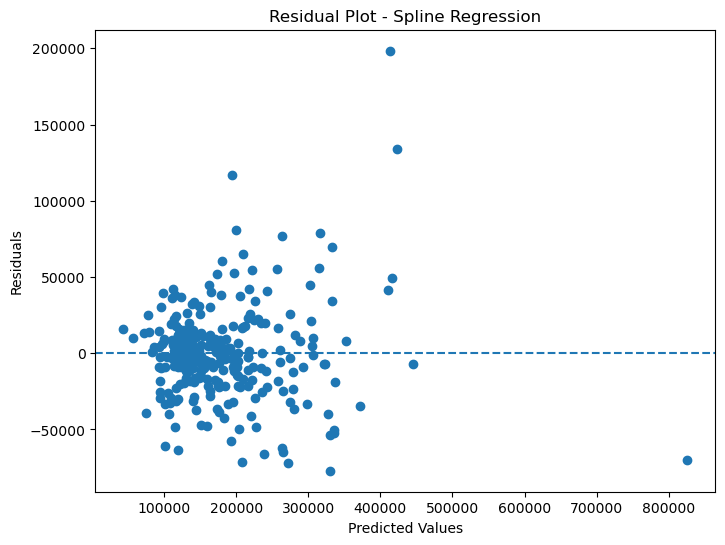

In [30]:
import matplotlib.pyplot as plt

residuals_spline = y_test - y_pred_spline

plt.figure(figsize=(8,6))
plt.scatter(y_pred_spline, residuals_spline)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Spline Regression")
plt.show()

In [ ]:
Residuals represent the difference between actual and predicted values.

Residual analysis helps in validating model assumptions:
- Random distribution indicates a good fit
- Patterns may indicate model limitations

A residual plot is used to visually analyze model performance.

In [31]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Spline Regression"],
    "R2 Score": [r2_lr, r2_spline],
    "Adjusted R2": [adj_r2_lr, adj_r2_spline],
    "RMSE": [rmse_lr, rmse_spline]
})

comparison

,Model,R2 Score,Adjusted R2,RMSE
0,Linear Regression,0.793865,0.790262,39763.295266
1,Spline Regression,0.877584,0.875444,30642.612750


In [ ]:
The performance of Multiple Linear Regression and Spline Regression is compared using evaluation metrics.

This comparison helps determine whether non-linear modeling provides better predictions than linear regression.

In [ ]:
This project analyzed house price prediction using both linear and non-linear regression techniques.

The linear regression model provided a strong baseline for understanding relationships between features and house prices.

The spline-based regression model, inspired by MARS, introduced flexibility by capturing non-linear patterns in the data.

Overall, spline regression demonstrated improved adaptability for complex datasets, making it a valuable approach for real-world prediction problems.